# Data Analytics - Week 02

- Overview about data analytics & it method
- Get familiar with panda library with python programming


## Case study of the lab: Retail Sales Decline

A company experienced 15% sales drop, they require us to **analyze the dataset** to help them **identify root cause** and ask us to **recommends actions**.

*Dataset file: DA02_Retail_Analytics_Large_Dataset.csv*

To do it, we have to start explore the dataset. After that we identify trends, by that we need to build a simple prediction model to present finding.

### PART 1 – Data Understanding & Descriptive Analytics

In [1]:
# Step 1: Load dataset
import pandas as pd
df = pd.read_csv('DA02_Retail_Analytics_Large_Dataset.csv')
df.head()

,Date,Marketing_Spend,Price_Index,Customer_Satisfaction,Competitor_Promo,Sales
0,1/31/2020,27.48,101.83,7.40,0,87.35
1,2/29/2020,24.31,104.54,6.74,0,78.28
2,3/31/2020,28.24,107.02,6.21,0,68.76
3,4/30/2020,32.62,108.46,7.66,0,88.45
4,5/31/2020,23.83,100.20,6.89,0,62.51


In [2]:
#Step 2: Summary statistics
df.describe()

,Marketing_Spend,Price_Index,Customer_Satisfaction,Competitor_Promo,Sales
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,24.988167,105.142667,7.449083,0.329167,68.243333
std,4.853972,3.959963,0.799913,0.470893,22.199127
min,11.900000,92.030000,5.340000,0.000000,20.000000
25%,21.572500,102.480000,6.890000,0.000000,52.522500
50%,25.310000,105.045000,7.450000,0.000000,69.620000
75%,27.962500,107.732500,7.972500,1.000000,83.200000
max,44.260000,117.320000,9.560000,1.000000,145.930000


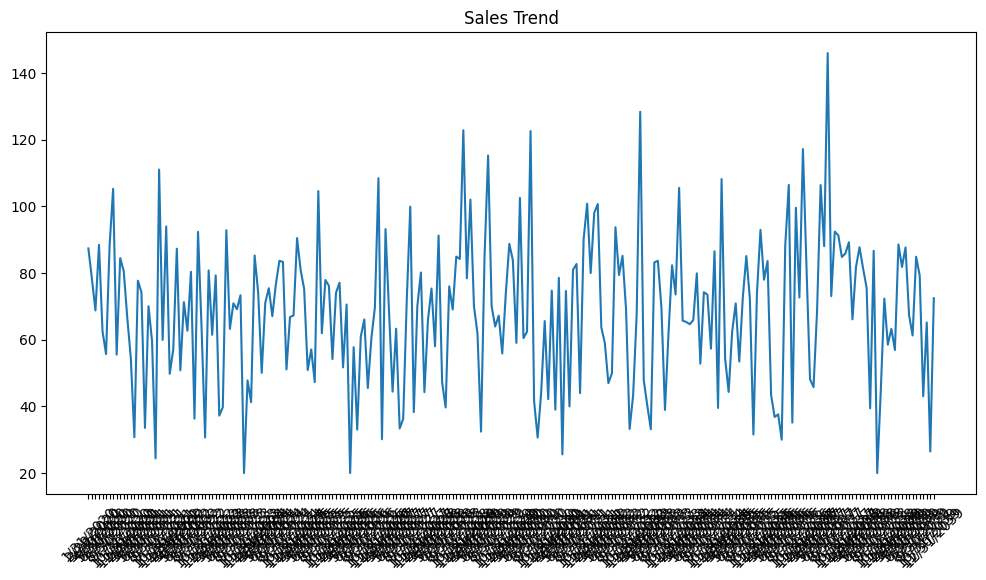

In [3]:
# Step 3: Sales Trend Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Sales'])
plt.title('Sales Trend')
plt.xticks(rotation=45)
plt.show()

#### Exercise 1

- What is average monthly sales?

In [ ]:
# Average monthly sales
df['Date'] = pd.to_datetime(df['Date']) 
df['Month'] = df['Date'].dt.to_period('M')
df.groupby('Month')['Sales'].mean()

Month
2020-01    87.35
2020-02    78.28
2020-03    68.76
2020-04    88.45
2020-05    62.51
           ...  
2039-08    79.27
2039-09    43.03
2039-10    65.14
2039-11    26.47
2039-12    72.44
Freq: M, Name: Sales, Length: 240, dtype: float64

- What is the highest sales month?

In [5]:
# Highest sales month (keep simple)
df.groupby(df['Date'].dt.to_period('M'))['Sales'].max().idxmax()

Period('2037-06', 'M')

- Is there an upward or downward trend?

In [6]:
# Is there an upward or downward trend? (entire dataset & keep simple)
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].median()
if monthly_sales.iloc[-1] > monthly_sales.iloc[0]:
    print("There is an upward trend in sales lately.")
else:
    print("There is a downward trend in sales lately.")

There is a downward trend in sales lately.


### PART 2 – Diagnostic Analytics

In [7]:
#Step 4: Correlation Matrix
df.corr(numeric_only=True)

,Marketing_Spend,Price_Index,Customer_Satisfaction,Competitor_Promo,Sales
Marketing_Spend,1.000000,-0.083251,0.019126,0.066604,0.657378
Price_Index,-0.083251,1.000000,-0.020106,-0.005813,-0.498884
Customer_Satisfaction,0.019126,-0.020106,1.000000,-0.124494,0.317496
Competitor_Promo,0.066604,-0.005813,-0.124494,1.000000,-0.293754
Sales,0.657378,-0.498884,0.317496,-0.293754,1.000000


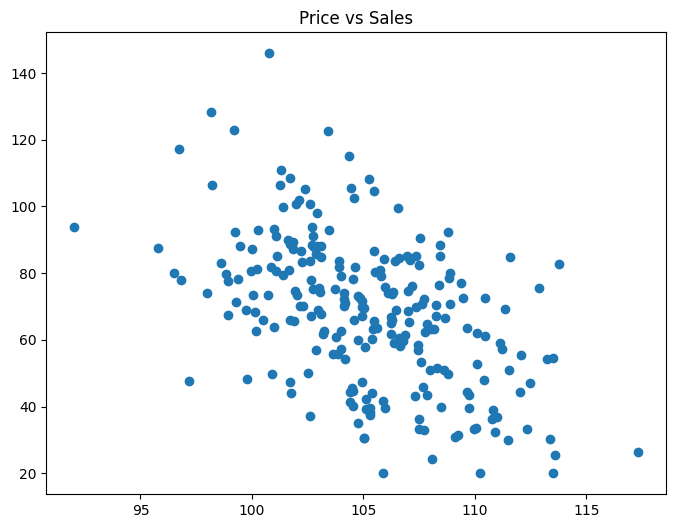

In [8]:
# Step 5: Relationship Visualization
plt.figure(figsize=(8, 6))
plt.scatter(df['Price_Index'], df['Sales'])
plt.title('Price vs Sales')
plt.show()

In [9]:
# Step 6: Competitor Impact
df.groupby("Competitor_Promo")['Sales'].mean()

Competitor_Promo
0    72.801739
1    58.953418
Name: Sales, dtype: float64

#### Exercise 2
- Which variable has strongest impact on sales?

In [10]:
#Which variable has the strongest impact on sales?
df.corr(numeric_only=True)['Sales'].abs().drop('Sales').idxmax()

'Marketing_Spend'

- Does competitor promotion reduce sales?

In [11]:
# Does competitor promotion reduce sales? (keep simple)
promo_sales = df[df['Competitor_Promo'] == 1]['Sales'].mean() # Calculate average sales when there is a competitor promotion
non_promo_sales = df[df['Competitor_Promo'] == 0]['Sales'].mean() # Calculate average sales when there is no competitor promotion
if promo_sales < non_promo_sales:
    print("Competitor promotion reduces sales.")
else:    print("Competitor promotion does not reduce sales.")

Competitor promotion reduces sales.


- Is higher satisfaction associated with higher sales?

In [12]:
# Is higher satisfaction associated with higher sales? (keep simple)
satisfaction_sales = df.groupby("Customer_Satisfaction")['Sales'].mean()
# Compare average sales at the highest and lowest satisfaction levels
if satisfaction_sales.iloc[0] > satisfaction_sales.iloc[1]: #iloc[0] is the lowest level, iloc[1] is the highest level
    print("Higher satisfaction is associated with higher sales.")
else:    print("Higher satisfaction is not associated with higher sales.")

Higher satisfaction is associated with higher sales.


### PART 3 – Predictive Analytics

In [13]:
#Step 7: Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df[['Marketing_Spend', 'Price_Index', 'Customer_Satisfaction', 'Competitor_Promo']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Score (R²):", model.score(X_test, y_test))
print("Coefficients:", model.coef_)

Model Score (R²): 0.7988436379681949
Coefficients: [  2.91055311  -2.4983202    6.67127584 -14.20920792]


#### Exercise 3

- Interpret coefficient of Price_Index.


In [14]:
# Interpret coefficients of Price_Index
print("Price_Index Coefficient:", model.coef_[1])

Price_Index Coefficient: -2.4983201967397353


- Which variable has largest impact?

In [15]:
# which variable has larger impact? (entirely X on absolute value of coefficients and keep simple)
coef_df = pd.DataFrame({'Variable': X.columns, 'Coefficient': model.coef_})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df.sort_values(by='Abs_Coefficient', ascending=False, inplace=True)
coef_df[['Variable', 'Coefficient']]

,Variable,Coefficient
3,Competitor_Promo,-14.209208
2,Customer_Satisfaction,6.671276
0,Marketing_Spend,2.910553
1,Price_Index,-2.498320


- What does R² indicate?

R² measures how well a regression model explains the variability of the target variable. In other words, it tells you what proportion of the variance in the dependent variable (Sales) is predictable from the independent variables (Marketing_Spend, Competitor_Promo, etc.).

Interpretation
- R² = 1.0 → Perfect fit. The model explains 100% of the variance.
- R² = 0.0 → The model explains nothing equivalent to just predicting the mean yˉ​ every time.
- R² < 0 → The model performs worse than a horizontal mean line (very poor fit).


Applied to the dataset we can see that R2=0.7988≈80%
The model explains 79.88% of the variance in Sales using the four features — Marketing_Spend, Price_Index, Customer_Satisfaction, and Competitor_Promo. The remaining 20.12% is attributed to factors not captured in the model.

### PART 4 – Prescriptive Analytics

In [16]:
# Step 8: Scenario Testing
# Scenario: Increase marketing by 5 units
scenario = model.predict([[30,105,8,0]]) # Example scenario with increased marketing spend
print("Predicted Sales:", scenario)

Predicted Sales: [91.66581753]


/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
# Step 9: Optimization Simulation
import numpy as np

budgets = np.arange(15, 40, 1) # Simulate different marketing budgets
results = []

for b in budgets:
    pred_sales = model.predict([[b, 105, 8, 0]]) # Predict sales for each budget
    results.append((b, pred_sales[0]))

best = max(results, key=lambda x: x[1])
print(f"Optimal Marketing Budget:", best[0], "with Expected Sales:", best[1])

Optimal Marketing Budget: 39 with Expected Sales: 117.86079549716962


/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/home/zhu/micromamba/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warni

#### Exercise 4
- What marketing budget maximizes predicted sales?

    From the output: Optimal Marketing Budget: 39 with Expected Sales: 117.86

    Budget = 39 units yields the highest predicted sales of ~117.86 across the simulated range of np.arange(15, 40, 1) — meaning the model was tested for every budget from 15 to 39, and 39 came out on top.

    This makes sense given Marketing_Spend has a positive coefficient (+2.91) — more spend → more sales, so the optimizer naturally hits the ceiling of the tested range (39).

    Worth noting: the simulation only goes up to 39. If you extend the range further, the optimal might shift higher — worth testing.

- Should the company raise or lower prices?

    Looking back at the coefficients: Price_Index → coefficient = -2.50

    Lower prices. Price_Index has a negative relationship with Sales — every unit increase in price is associated with a ~2.50 unit drop in predicted sales.

    However, this is a trade-off decision: ActionSales impactRevenue impactLower price↑ Sales volumeDepends on marginRaise price↓ Sales volumeHigher per-unit revenue

    The model only predicts volume, not profit — so the final answer depends on the company's margin structure. If margins are thin, lowering price to drive volume may not be worth it.